# Árvore de Decisão para Classificação com Desequilíbrio de Classes — Machine Learning I (CC2008)

**Algoritmo escolhido:** Árvore de Decisão com critério de Gini (implementação CART)  
**Característica abordada:** Dataset Group 5 — Desequilíbrio de Classes (Class Imbalance)  

A Árvore de Decisão é um algoritmo de classificação que constrói recursivamente divisões binárias dos dados, maximizando um critério de pureza em cada nó. Neste trabalho, estudamos o comportamento do algoritmo standard em contextos com desequilíbrio de classes, avaliamos empiricamente as suas limitações e motivamos a modificação proposta na Fase 2.

## Setup Inicial

Importação das dependências. Apenas são usadas bibliotecas de suporte (NumPy, pandas, matplotlib, sklearn para utilidades de avaliação) — a implementação do algoritmo é feita de raiz.

In [50]:
import numpy as np
import pandas as pd
import random
import warnings
from functools import partial
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

# ── Configuração global ───────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 5
MAX_DEPTH    = 5
MIN_SAMPLES  = 5
MAX_SAMPLES  = 500   
DATA_DIR     = Path('data/class_imbalance/class_imbalance')

## Critério de Impureza de Gini

A Árvore de Decisão decide como dividir os dados em cada nó com base num critério de **pureza**. O critério standard para classificação é o **índice de Gini**:

$$\text{Gini}(S) = 1 - \sum_{c=1}^{k} p_c^2$$

onde $p_c$ é a proporção da classe $c$ no conjunto $S$, e $k$ é o número de classes. Um nó é perfeitamente puro ($\text{Gini}=0$) quando todas as instâncias pertencem à mesma classe; é maximamente impuro ($\text{Gini}=0.5$ para $k=2$) quando as classes estão em proporções iguais.

O **ganho de Gini** para uma divisão $S \to S_L \cup S_R$ é:

$$\Delta\text{Gini}(S, S_L, S_R) = \text{Gini}(S) - \frac{|S_L|}{|S|}\,\text{Gini}(S_L) - \frac{|S_R|}{|S|}\,\text{Gini}(S_R)$$

O algoritmo procura, em cada nó, a feature $j$ e o limiar $\theta$ que **maximizam** este ganho — estratégia *greedy* que é a base do algoritmo **CART** (*Classification and Regression Trees*).

As funções auxiliares de divisão dos dados são apresentadas abaixo.

In [51]:
def split(X_col, y, value):
    """Separa os rótulos y pelo limiar value aplicado à coluna X_col."""
    y = np.asarray(y).ravel()
    left_mask = X_col < value
    return y[left_mask], y[~left_mask]


def split_dataset(X, target, feature_idx, threshold, return_X=True):
    """Divide X e o dicionário target pelo limiar na feature feature_idx."""
    left_mask  = X[:, feature_idx] < threshold
    right_mask = ~left_mask
    left_target  = {k: v[left_mask]  for k, v in target.items()}
    right_target = {k: v[right_mask] for k, v in target.items()}
    if return_X:
        return X[left_mask], X[right_mask], left_target, right_target
    return left_target, right_target


print("Funções auxiliares de divisão definidas.")

Funções auxiliares de divisão definidas.


## Implementação da Árvore de Decisão (de raiz)

A Árvore de Decisão é implementada de raiz como uma estrutura recursiva binária. Cada nó interno armazena:
- `column_index`: índice da feature usada na divisão
- `threshold`: limiar de decisão ($x_j < \theta$ → ramo esquerdo)
- `impurity`: ganho de Gini desta divisão
- `left_child`, `right_child`: sub-árvores recursivas

Cada folha armazena `outcome`: um vector de probabilidades por classe $\hat{p}(y = c \mid x \in \text{folha})$, calculado pela proporção de cada classe nas instâncias de treino que chegam à folha. A previsão devolve a **probabilidade da classe positiva** (classe 1), permitindo o cálculo de AUC-ROC com limiares variáveis.

O treino segue o algoritmo CART:
1. Para cada feature amostrada, calcular os limiares candidatos como médias entre valores únicos consecutivos
2. Escolher a divisão com maior ganho de Gini
3. Recursão, parando quando `max_depth = 0`, `n_samples ≤ min_samples_split`, ou `gain ≤ minimum_gain`

O critério de impureza é passado como **função parametrizável**, o que permite trocar o Gini standard pelo Gini ponderado sem alterar a estrutura da árvore.

In [52]:
class Tree(object):
    """Implementação recursiva de uma árvore de decisão binária."""

    def __init__(self, regression=False, criterion=None, n_classes=None):
        self.regression    = regression
        self.criterion     = criterion
        self.n_classes     = n_classes
        self.impurity      = None
        self.threshold     = None
        self.column_index  = None
        self.outcome       = None
        self.loss          = None
        self.left_child    = None
        self.right_child   = None

    @property
    def is_terminal(self):
        return not bool(self.left_child and self.right_child)

    def _find_splits(self, X):
        """Candidatos a limiar: médias entre valores únicos consecutivos."""
        x_unique = np.unique(X)
        return [(x_unique[i - 1] + x_unique[i]) / 2.0 for i in range(1, len(x_unique))]

    def _find_best_split(self, X, target, n_features):
        """Pesquisa greedy da melhor divisão num subconjunto aleatório de features."""
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                splits = split(X[:, column], target["y"], value)
                gain   = self.criterion(target["y"], splits)
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = Tree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = Tree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)

    def train(self, X, target, max_features=None, min_samples_split=10,
              max_depth=None, minimum_gain=0.0):
        """Treina a árvore a partir de X (features) e target (rótulos)."""
        if not isinstance(target, dict):
            target = {"y": np.asarray(target, dtype=int)}
        if not self.regression:
            self.n_classes = len(np.unique(target["y"]))
        self._train(X, target, max_features=max_features,
                    min_samples_split=min_samples_split,
                    max_depth=max_depth, minimum_gain=minimum_gain)

    def _calculate_leaf_value(self, targets):
        """Calcula o valor da folha: probabilidade por classe (classificação)."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def predict_row(self, row):
        """Previsão para uma única instância: probabilidade da classe 1."""
        if not self.is_terminal:
            child = self.left_child if row[self.column_index] < self.threshold \
                    else self.right_child
            return child.predict_row(row)
        if isinstance(self.outcome, np.ndarray):
            return self.outcome[1]   # P(y=1)
        return float(self.outcome)

    def predict(self, X):
        """Devolve P(y=1) para cada linha de X."""
        return np.array([self.predict_row(X[i]) for i in range(X.shape[0])])


print("Classe Tree definida (CART, critério parametrizável).")

Classe Tree definida (CART, critério parametrizável).


## Árvore de Decisão e Desequilíbrio de Classes — Análise Teórica

### O Problema do Desequilíbrio de Classes

Em datasets com desequilíbrio de classes (*class imbalance*), a proporção de instâncias da classe minoritária é muito pequena — neste grupo de datasets, o *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$) varia entre 0.007 e 0.24. Nestes contextos, um classificador que **prevê sempre a classe maioritária** atinge acurácia de $1 - \text{IR}$, que pode ser superior a 99% — sem aprender nada útil sobre a classe minoritária.

### Por que o Gini Standard é Problemático?

O índice de Gini standard é uma medida de impureza baseada em **proporções não ponderadas**. Em dados muito desbalanceados, isto gera três problemas:

**1. Divisões que ignoram a classe minoritária são recompensadas.**  
Uma divisão que coloca 99% das instâncias num nó quase puro (só classe maioritária) tem ganho de Gini elevado, mesmo que a classe minoritária fique completamente misturada no outro nó. O algoritmo "aprende" a ignorar a classe minoritária porque isso maximiza o Gini.

**2. Folhas maioritárias dominam a predição.**  
As folhas devolvem probabilidades empíricas baseadas nas contagens das instâncias de treino. Nós com muitas instâncias da classe maioritária produzem folhas com $\hat{p}(y=1)$ muito baixo, enviesando o modelo.

**3. O limiar de decisão standard de 0.5 é inapropriado.**  
Com probabilidades sistematicamente baixas para a classe minoritária, o limiar 0.5 faz com que o modelo raramente preveja essa classe, resultando em F1 e G-mean próximos de zero apesar de uma acurácia elevada.

### Hipótese

> O desequilíbrio de classes afecta negativamente e de forma mensurável o desempenho da Árvore de Decisão com Gini standard, especialmente nas métricas F1 e G-mean da classe minoritária. A degradação deverá ser proporcional à severidade do desequilíbrio (IR baixo). Esta hipótese será avaliada empiricamente na Fase 1.

In [53]:
def gini_impurity(y, splits):
    """Ganho de Gini standard (não ponderado)."""
    y_left, y_right = splits
    if len(y_left) == 0 or len(y_right) == 0:
        return 0

    def _gini(labels):
        if len(labels) == 0:
            return 0
        probs = np.bincount(labels) / len(labels)
        return 1 - np.sum(probs ** 2)

    n = len(y_left) + len(y_right)
    parent = _gini(np.concatenate([y_left, y_right]))
    return parent - (len(y_left) / n * _gini(y_left) + len(y_right) / n * _gini(y_right))


print("Critério de Gini standard definido.")

Critério de Gini standard definido.


In [54]:
def gini_impurity_weighted(y, splits, w, w_splits):
    """
    Ganho de Gini ponderado por peso de instância (Weighted CART).
    w_i = n / (2 · n_{y_i})  →  class_weight='balanced'.

    Ting, K.M. (2002). An instance-weighting method to induce cost-sensitive trees.
    IEEE Transactions on Knowledge and Data Engineering, 14(3), 659–669.
    """
    y_left, y_right = splits
    w_left, w_right = w_splits

    if len(y_left) == 0 or len(y_right) == 0:
        return 0.0

    n_cls = int(y.max()) + 1

    def _gini_w(labels, weights):
        if len(labels) == 0 or weights.sum() == 0:
            return 0.0
        wc = np.array([weights[labels == c].sum() for c in range(n_cls)])
        p  = wc / wc.sum()
        return 1.0 - np.sum(p ** 2)

    wt_l, wt_r = w_left.sum(), w_right.sum()
    wt = wt_l + wt_r
    parent = _gini_w(np.concatenate([y_left, y_right]), np.concatenate([w_left, w_right]))
    child  = wt_l / wt * _gini_w(y_left, w_left) + wt_r / wt * _gini_w(y_right, w_right)
    return parent - child


print("Critério de Gini ponderado definido:")
print("  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669")

Critério de Gini ponderado definido:
  · gini_impurity_weighted  — Ting (2002), IEEE TKDE 14(3), pp. 659–669


## Datasets — Carregamento e Pré-processamento

Seleccionámos **11 datasets** com **Class Imbalance** com diversidade em:
- *Imbalance Ratio* (IR = $n_{\text{min}} / n_{\text{max}}$): de 0.046 a 0.235
- dimensionalidade (4 a 56 features)
- tamanho (107 a 500 instâncias após amostragem)

Os 9 datasets "problemáticos" (com degradação esperada do Gini standard) contrastam com 2 datasets onde o algoritmo funciona bem apesar do desequilíbrio (*Sick*, *Hypothyroid*), permitindo distinguir o efeito do IR do efeito da separabilidade das features.

**Critério de exclusão**: datasets com menos de 20 instâncias da classe minoritária após amostragem estratificada a 500 são excluídos — abaixo deste limiar, cada fold de treino tem ≤ 15 exemplos da classe rara, tornando a estimativa de desempenho estatisticamente infiável. *Chlamydia* (n=100, n_min=19) foi excluído por este critério.

### Pipeline de pré-processamento
1. **Coluna alvo**: a última coluna de cada CSV (convenção uniforme do Dataset Group 5)
2. **Codificação de features categóricas** via `LabelEncoder`
3. **Imputação de valores em falta** com zero
4. **Amostragem estratificada** para datasets com mais de 500 instâncias — preserva o IR original
5. **Verificação de binariedade**: datasets com mais de 2 classes são excluídos da análise

In [55]:
DATASETS = [
    # IR severo — falham claramente mas o modelo aprende (AUC > 0.60)
    ("dataset_311_oil_spill.csv",              "Oil-Spill"),      # IR=0.046
    ("dataset_1018_ipums_la_99-small.csv",     "IPUMS-99"),       # IR=0.068
    ("dataset_1065_kc3.csv",                   "KC3"),            # IR=0.104
    ("dataset_1050_pc3.csv",                   "PC3"),            # IR=0.114
    ("dataset_757_meta.csv",                   "Meta"),           # IR=0.114
    ("dataset_1002_ipums_la_98-small.csv",     "IPUMS-98"),       # IR=0.119
    ("dataset_1049_pc4.csv",                   "PC4"),            # IR=0.139
    ("dataset_949_arsenic-female-bladder.csv", "Arsenic-FB"),     # IR=0.168
    ("dataset_1061_ar4.csv",                   "AR4"),            # IR=0.230
    # Contraste — algoritmo funciona bem (separabilidade alta apesar do IR)
    ("dataset_38_sick.csv",                    "Sick"),           # IR=0.066
    ("dataset_1000_hypothyroid.csv",           "Hypothyroid"),    # IR=0.085
]



def load_dataset(filename, max_samples=MAX_SAMPLES, random_state=RANDOM_STATE):
    """
    Carrega e pré-processa um dataset CSV do grupo Class Imbalance.
    Retorna X (array float), y (array int binário), ir (imbalance ratio).
    Retorna (None, None, None) se o dataset não for binário.
    """
    path = DATA_DIR / filename
    df   = pd.read_csv(path)

    target_col = df.columns[-1]
    X_df       = df.iloc[:, :-1].copy()
    y_raw      = df[target_col].values

    for col in X_df.columns:
        if X_df[col].dtype == 'object':
            X_df[col] = LabelEncoder().fit_transform(X_df[col].astype(str))

    X_df = X_df.apply(pd.to_numeric, errors='coerce')
    X    = X_df.fillna(0).values.astype(float)

    le_y = LabelEncoder()
    y    = le_y.fit_transform(y_raw.astype(str)).astype(int)

    if len(np.unique(y)) != 2:
        return None, None, None

    # Garantir que a classe minoritária é sempre label 1.
    # O LabelEncoder atribui labels por ordem alfabética dos valores originais,
    # o que pode colocar a classe maioritária como label 1 — invertendo o
    # significado de F1 e das probabilidades P(y=1) devolvidas pela árvore.
    counts = np.bincount(y)
    if counts[0] < counts[1]:
        y = 1 - y

    if len(y) > max_samples:
        sss = StratifiedShuffleSplit(n_splits=1, train_size=max_samples,
                                     random_state=random_state)
        idx, _ = next(sss.split(X, y))
        X, y   = X[idx], y[idx]

    counts = np.bincount(y)
    ir     = round(counts.min() / counts.max(), 3)
    return X, y, ir


print(f"{'Dataset':<15} {'n_samples':>10} {'n_features':>12} {'n_min':>7} {'n_maj':>7} {'IR':>8}")
print("-" * 62)
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        print(f"{name:<15} {'(multiclasse — excluído)'}")
        continue
    counts = np.bincount(y)
    print(f"{name:<15} {X.shape[0]:>10} {X.shape[1]:>12} {counts.min():>7} {counts.max():>7} {ir:>8.3f}")

Dataset          n_samples   n_features   n_min   n_maj       IR
--------------------------------------------------------------
Oil-Spill              500           49      22     478    0.046
IPUMS-99               500           56      32     468    0.068
KC3                    458           39      43     415    0.104
PC3                    500           37      51     449    0.114
Meta                   500           21      51     449    0.114
IPUMS-98               500           55      53     447    0.119
PC4                    500           37      61     439    0.139
Arsenic-FB             500            4      72     428    0.168
AR4                    107           29      20      87    0.230
Sick                   500           29      31     469    0.066
Hypothyroid            500           29      39     461    0.085


## Avaliação Experimental — Setup

### Metodologia
- **Validação cruzada estratificada com 5 folds** (Stratified 5-Fold CV)  
  Garante que cada fold mantém o IR original do dataset — essencial em dados desbalanceados, onde um fold não estratificado poderia conter zero instâncias da classe minoritária.
- **Resultados reportados como média ± desvio-padrão** ao longo dos 5 folds.

### Métricas reportadas

A acurácia é ignorada por ser enganosa em datasets desbalanceados. São reportadas três métricas sensíveis ao desequilíbrio:

- **AUC-ROC** — Área sob a curva ROC; mede a capacidade de separação independentemente do limiar de decisão. Robusta a desbalanceamento.
- **F1-Score** (classe minoritária) — Média harmónica de precisão e recall para a classe 1. Directamente afectada pelo número de falsos negativos.
- **G-mean** (Média Geométrica) — $\sqrt{\text{Sensibilidade} \times \text{Especificidade}}$. Penaliza fortemente o classificador que ignora uma das classes, mesmo que a outra esteja bem classificada.

### Hiperparâmetros
- `max_depth = 5` — profundidade moderada para evitar overfitting em datasets pequenos
- `min_samples_split = 5` — nós com menos de 5 instâncias tornam-se folhas
- `minimum_gain = 0.0` — nenhum ganho mínimo forçado (relevante para datasets com IR muito baixo)

In [56]:
def gmean_score(y_true, y_pred):
    """Média geométrica de sensibilidade e especificidade."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return np.sqrt(sens * spec)


def run_cv(X, y, criterion_fn):
    """
    Validação cruzada estratificada com 5 folds.
    criterion_fn: função com assinatura criterion(y, splits) -> float
    Retorna dicionário com {métrica: (média, desvio_padrão)}.
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).")

Funções de avaliação definidas (G-mean, F1, AUC-ROC, validação cruzada).


In [57]:
class WeightedTree(Tree):
    """
    Extensão isolada de Tree para Weighted CART (Ting 2002; Breiman et al. 1984).
    A classe Tree base não é modificada.

    Sobrepõe três métodos internos:
      · _find_best_split      — usa gini_impurity_weighted com pesos por instância
      · _calculate_leaf_value — calcula P(y=1) por contagens ponderadas
      · _train                — cria filhos como WeightedTree (não Tree) para
                                preservar o comportamento ponderado em toda a árvore
    """

    def _find_best_split(self, X, target, n_features):
        y = target["y"]
        w = target.get("w", np.ones(len(y)))
        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                mask     = X[:, column] < value
                y_l, y_r = y[mask], y[~mask]
                w_l, w_r = w[mask], w[~mask]
                gain = self.criterion(y, (y_l, y_r), w, (w_l, w_r))
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _calculate_leaf_value(self, targets):
        y = targets["y"].astype(int)
        w = targets.get("w", np.ones(len(y)))
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        wc = np.array([w[y == c].sum() for c in range(self.n_classes)])
        self.outcome = wc / wc.sum()

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            # Criar filhos como WeightedTree para preservar pesos em toda a arvore
            self.left_child = WeightedTree(self.regression, self.criterion, self.n_classes)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = WeightedTree(self.regression, self.criterion, self.n_classes)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)


def run_cv_weighted(X, y):
    """
    CV estratificada com Weighted CART:
      · pesos balanceados w_i = n / (2·n_{y_i}) calculados por fold de treino
      · WeightedTree propaga pesos em splits e folhas em toda a arvore
      · threshold de previsao: 0.5
    """
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr)
        X_te = scaler.transform(X_te)

        n      = len(y_tr)
        counts = np.bincount(y_tr, minlength=2)
        w_cls  = n / (2 * np.where(counts > 0, counts, 1))
        sample_w = w_cls[y_tr]

        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": sample_w},
                   max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > 0.5).astype(int)

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))

    return dict(
        auc   = (np.mean(aucs),   np.std(aucs)),
        f1    = (np.mean(f1s),    np.std(f1s)),
        gmean = (np.mean(gmeans), np.std(gmeans)),
    )


print("WeightedTree e run_cv_weighted definidos.")

WeightedTree e run_cv_weighted definidos.


## Resultados — Fase 1: Gini Standard (Baseline)

A Fase 1 avalia o desempenho da Árvore de Decisão CART com o critério de **Gini standard** nos 11 datasets com condições base (`max_depth=5`, sem pruning). Estes resultados estabelecem o baseline contra o qual a Fase 2 é comparada.

In [58]:
import time

records = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    counts = np.bincount(y)
    row    = {"Dataset": name, "n": len(y), "n_features": X.shape[1],
              "n_min": counts.min(), "n_maj": counts.max(), "ir": ir}

    t0      = time.time()
    std_res = run_cv(X, y, gini_impurity)
    t_std   = time.time() - t0

    row.update({
        "std_auc": f"{std_res['auc'][0]:.3f} ± {std_res['auc'][1]:.3f}",
        "std_f1":  f"{std_res['f1'][0]:.3f} ± {std_res['f1'][1]:.3f}",
        "std_gm":  f"{std_res['gmean'][0]:.3f} ± {std_res['gmean'][1]:.3f}",
        "_std_auc": std_res['auc'][0],
        "_std_f1":  std_res['f1'][0],
        "_std_gm":  std_res['gmean'][0],
    })
    records.append(row)

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1={std_res['f1'][0]:.3f} | "
          f"AUC={std_res['auc'][0]:.3f} | "
          f"G-mean={std_res['gmean'][0]:.3f}  ({t_std:.1f}s)")

df_results = pd.DataFrame(records)
print(f"\nAvaliação concluída. ({len(df_results)} datasets analisados)")

  Oil-Spill      IR=0.046 | F1=0.438 | AUC=0.691 | G-mean=0.619  (4.0s)
  IPUMS-99       IR=0.068 | F1=0.081 | AUC=0.627 | G-mean=0.161  (0.8s)
  KC3            IR=0.104 | F1=0.241 | AUC=0.660 | G-mean=0.346  (1.4s)
  PC3            IR=0.114 | F1=0.255 | AUC=0.577 | G-mean=0.444  (2.2s)
  Meta           IR=0.114 | F1=0.000 | AUC=0.762 | G-mean=0.000  (0.2s)
  IPUMS-98       IR=0.119 | F1=0.000 | AUC=0.647 | G-mean=0.000  (0.7s)
  PC4            IR=0.139 | F1=0.413 | AUC=0.829 | G-mean=0.614  (1.7s)
  Arsenic-FB     IR=0.168 | F1=0.294 | AUC=0.771 | G-mean=0.442  (0.3s)
  AR4            IR=0.230 | F1=0.458 | AUC=0.665 | G-mean=0.592  (0.6s)
  Sick           IR=0.066 | F1=0.832 | AUC=0.930 | G-mean=0.890  (0.3s)
  Hypothyroid    IR=0.085 | F1=0.764 | AUC=0.927 | G-mean=0.881  (0.2s)

Avaliação concluída. (11 datasets analisados)


In [59]:
cols_display = ["Dataset", "n", "ir", "std_auc", "std_f1", "std_gm"]
df_show = df_results[cols_display].copy()
df_show.columns = ["Dataset", "N", "IR", "AUC-ROC", "F1 (min)", "G-mean"]
df_show = df_show.sort_values("IR")

print("Resultados — Gini standard (Stratified 5-Fold CV)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────")
for label, col in [("AUC-ROC", "_std_auc"), ("F1     ", "_std_f1"), ("G-mean ", "_std_gm")]:
    print(f"  {label}  {df_results[col].mean():.3f}")

Resultados — Gini standard (Stratified 5-Fold CV)

    Dataset   N    IR       AUC-ROC      F1 (min)        G-mean
  Oil-Spill 500 0.046 0.691 ± 0.093 0.438 ± 0.167 0.619 ± 0.133
       Sick 500 0.066 0.930 ± 0.061 0.832 ± 0.074 0.890 ± 0.069
   IPUMS-99 500 0.068 0.627 ± 0.067 0.081 ± 0.100 0.161 ± 0.197
Hypothyroid 500 0.085 0.927 ± 0.037 0.764 ± 0.075 0.881 ± 0.070
        KC3 458 0.104 0.660 ± 0.071 0.241 ± 0.203 0.346 ± 0.283
        PC3 500 0.114 0.577 ± 0.086 0.255 ± 0.061 0.444 ± 0.076
       Meta 500 0.114 0.762 ± 0.082 0.000 ± 0.000 0.000 ± 0.000
   IPUMS-98 500 0.119 0.647 ± 0.052 0.000 ± 0.000 0.000 ± 0.000
        PC4 500 0.139 0.829 ± 0.058 0.413 ± 0.129 0.614 ± 0.158
 Arsenic-FB 500 0.168 0.771 ± 0.089 0.294 ± 0.088 0.442 ± 0.074
        AR4 107 0.230 0.665 ± 0.163 0.458 ± 0.180 0.592 ± 0.111

── Médias globais ─────────────────────────────────────────
  AUC-ROC  0.735
  F1       0.343
  G-mean   0.453


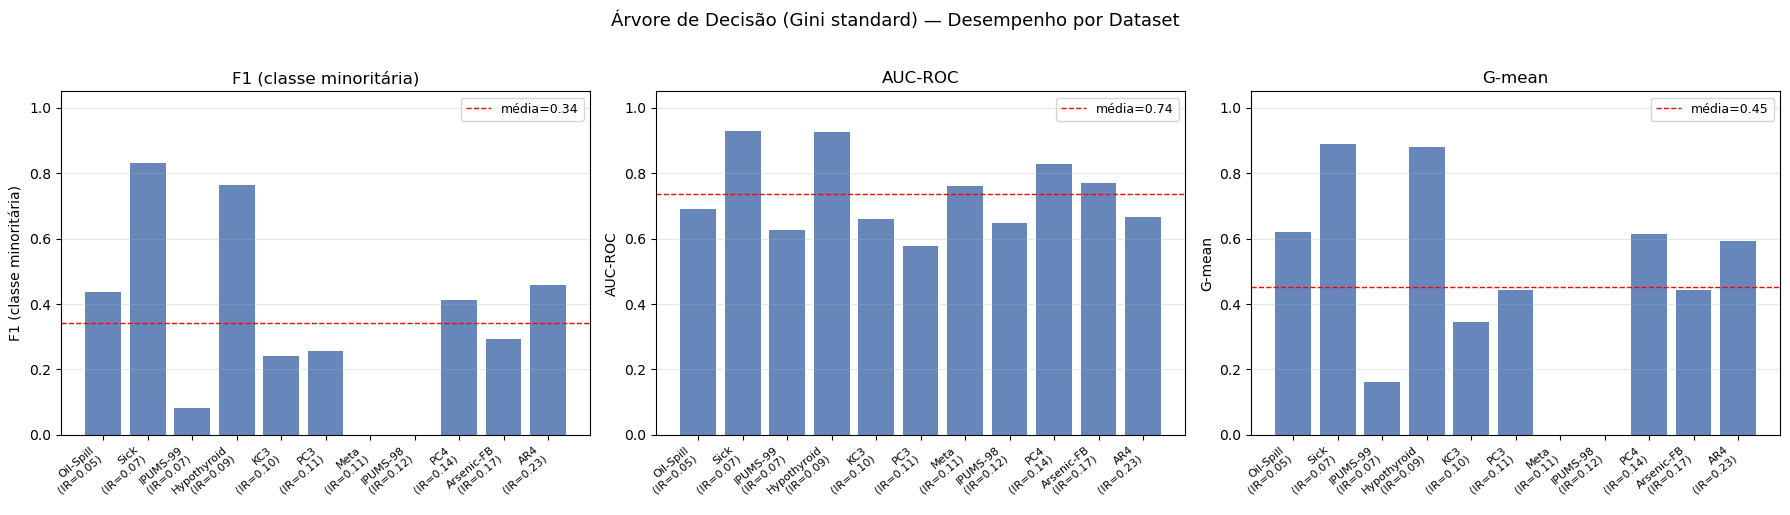

Figura guardada em results_main/resultados_fase1.png


In [60]:
RESULTS_DIR = Path("results_main")
RESULTS_DIR.mkdir(exist_ok=True)

metrics_cfg = [
    ("F1 (classe minoritária)", "_std_f1"),
    ("AUC-ROC",                 "_std_auc"),
    ("G-mean",                  "_std_gm"),
]

df_s = df_results.sort_values("ir")
x    = np.arange(len(df_s))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, col) in zip(axes, metrics_cfg):
    ax.bar(x, df_s[col], color="#4C72B0", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_s.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(name)
    ax.set_title(name)
    ax.axhline(df_s[col].mean(), color="red", linestyle="--", linewidth=1,
               label=f"média={df_s[col].mean():.2f}")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Árvore de Decisão (Gini standard) — Desempenho por Dataset", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "resultados_fase1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/resultados_fase1.png")

## Análise dos Resultados — Fase 1

**O Gini standard falha em dois pontos do algoritmo, em simultâneo.**

**Mecanismo 1 — Splits enviesados:**
O ganho de Gini é calculado como redução de impureza em relação ao nó pai. Quando as classes estão desbalanceadas, a impureza do pai é dominada pela classe maioritária — splits que isolam instâncias dessa classe produzem ganhos elevados mesmo que a classe minoritária fique completamente misturada no ramo oposto. O algoritmo não tem nenhum incentivo para "procurar" positivos raros.

**Mecanismo 2 — Folhas enviesadas:**
Nas folhas, $\hat{p}(y=1)$ é calculado como contagem bruta: $\hat{p} = n_+ / (n_+ + n_-)$. Com IR baixo, $n_+ \ll n_-$, pelo que $\hat{p}$ é sistematicamente inferior a 0.5 em quase todas as folhas — incluindo folhas com concentração relativa de positivos. Com o limiar $\tau = 0.5$, nenhuma instância é classificada como positiva, mesmo que o modelo tenha aprendido alguma separação (AUC > 0.5).

**A consequência directa:**
F1 e G-mean colapsam para zero enquanto AUC mantém valores razoáveis. Este desacoplamento entre AUC e F1/G-mean é o sinal diagnóstico do problema: o modelo *ordena* correctamente as probabilidades (AUC) mas não consegue *activar* a classe minoritária com o limiar fixo (F1 = 0).

**Conclusão:**
Para resolver class imbalance, qualquer modificação ao algoritmo tem de actuar em pelo menos um destes dois pontos — splits ou folhas. As Fases 2 e 3 abordam cada um por mecanismos distintos.

### Nota sobre o AUC como indicador de separabilidade latente

O AUC-ROC é invariante ao limiar de decisão: mede apenas se o modelo *ordena* correctamente as instâncias por probabilidade, independentemente de onde se corta. Em dados desbalanceados, é possível ter AUC > 0.5 com F1 = 0 — o modelo aprendeu algo, mas o limiar fixo $\tau = 0.5$ impede que esse conhecimento se materialize em previsões da classe minoritária.

Este padrão tem uma interpretação algorítmica clara:
- **AUC > 0.5, F1 = 0**: o Gini standard construiu divisões com algum poder discriminativo, mas as folhas emitem $\hat{p}(y=1) < 0.5$ em todos os nós — problema nas *folhas*.
- **AUC ≈ 0.5, F1 = 0**: não há separabilidade aprendida — problema nos *splits* (o critério não encontrou divisões úteis).

O primeiro caso é resolvido corrigindo as folhas (Weighted Gini — Fase 2). O segundo exige um critério de split mais sensível à classe rara (Hellinger Distance — Fase 3) ou mais dados.

---

## Fase 2 — Weighted CART (Gini Ponderado com Árvore Balanceada)

A Fase 1 identificou as limitações do Gini standard em dados desbalanceados. A Fase 2 aplica o **Weighted CART** (`WeightedTree`) com Gini ponderado (Ting, 2002), mantendo as mesmas condições (`max_depth=5`, sem pruning). Os pesos de instância balanceiam as classes em splits e folhas:

$$w_i = \frac{n}{2 \cdot n_{y_i}} \quad \Rightarrow \quad \sum_{y_i=0} w_i = \sum_{y_i=1} w_i$$

- **Splits ponderados** (`WeightedTree._find_best_split`): valorizam divisões que concentram a classe minoritária, mesmo quando ela é rara.
- **Folhas ponderadas** (`WeightedTree._calculate_leaf_value`): $\hat{p}(y=1|\text{folha}) = \frac{\sum w[y=1]}{\sum w}$ — uma folha com 10% de positivos e IR=0.10 passa de $\hat{p}=0.10$ para $\hat{p}\approx0.50$, activando previsões da classe minoritária com o limiar standard.

A classe `Tree` base não é modificada — `WeightedTree` é uma extensão isolada.

In [61]:
import time

records_wg = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0     = time.time()
    wg_res = run_cv_weighted(X, y)
    t_wg   = time.time() - t0

    f1_std = df_results.loc[df_results["Dataset"] == name, "_std_f1"].values[0]

    records_wg.append({"Dataset": name, "ir": ir,
                        "_wg_auc": wg_res["auc"][0],   "_wg_auc_std": wg_res["auc"][1],
                        "_wg_f1":  wg_res["f1"][0],    "_wg_f1_std":  wg_res["f1"][1],
                        "_wg_gm":  wg_res["gmean"][0], "_wg_gm_std":  wg_res["gmean"][1],
                        "wg_f1_fmt":  f"{wg_res['f1'][0]:.3f} ± {wg_res['f1'][1]:.3f}",
                        "wg_gm_fmt":  f"{wg_res['gmean'][0]:.3f} ± {wg_res['gmean'][1]:.3f}",
                        "wg_auc_fmt": f"{wg_res['auc'][0]:.3f} ± {wg_res['auc'][1]:.3f}"})

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1  Gini={f1_std:.3f}  →  WG={wg_res['f1'][0]:.3f}±{wg_res['f1'][1]:.3f}  ({t_wg:.1f}s)")

df_wg = pd.DataFrame(records_wg)
print("\nWeighted Gini avaliado.")

  Oil-Spill      IR=0.046 | F1  Gini=0.438  →  WG=0.286±0.101  (7.2s)
  IPUMS-99       IR=0.068 | F1  Gini=0.081  →  WG=0.181±0.032  (1.5s)
  KC3            IR=0.104 | F1  Gini=0.241  →  WG=0.321±0.042  (3.4s)
  PC3            IR=0.114 | F1  Gini=0.255  →  WG=0.355±0.085  (5.0s)
  Meta           IR=0.114 | F1  Gini=0.000  →  WG=0.320±0.052  (0.3s)
  IPUMS-98       IR=0.119 | F1  Gini=0.000  →  WG=0.301±0.040  (1.6s)
  PC4            IR=0.139 | F1  Gini=0.413  →  WG=0.528±0.041  (3.6s)
  Arsenic-FB     IR=0.168 | F1  Gini=0.294  →  WG=0.384±0.098  (0.6s)
  AR4            IR=0.230 | F1  Gini=0.458  →  WG=0.497±0.158  (1.3s)
  Sick           IR=0.066 | F1  Gini=0.832  →  WG=0.804±0.079  (0.7s)
  Hypothyroid    IR=0.085 | F1  Gini=0.764  →  WG=0.818±0.066  (0.4s)

Weighted Gini avaliado.


Comparação — Gini standard vs Weighted Gini (depth=5, sem pruning)

    Dataset    IR     F1 (Gini)       F1 (WG) G-mean (Gini)   G-mean (WG)
  Oil-Spill 0.046 0.438 ± 0.167 0.286 ± 0.101 0.619 ± 0.133 0.603 ± 0.127
       Sick 0.066 0.832 ± 0.074 0.804 ± 0.079 0.890 ± 0.069 0.888 ± 0.068
   IPUMS-99 0.068 0.081 ± 0.100 0.181 ± 0.032 0.161 ± 0.197 0.600 ± 0.073
Hypothyroid 0.085 0.764 ± 0.075 0.818 ± 0.066 0.881 ± 0.070 0.922 ± 0.043
        KC3 0.104 0.241 ± 0.203 0.321 ± 0.042 0.346 ± 0.283 0.673 ± 0.065
        PC3 0.114 0.255 ± 0.061 0.355 ± 0.085 0.444 ± 0.076 0.676 ± 0.097
       Meta 0.114 0.000 ± 0.000 0.320 ± 0.052 0.000 ± 0.000 0.701 ± 0.074
   IPUMS-98 0.119 0.000 ± 0.000 0.301 ± 0.040 0.000 ± 0.000 0.674 ± 0.050
        PC4 0.139 0.413 ± 0.129 0.528 ± 0.041 0.614 ± 0.158 0.822 ± 0.019
 Arsenic-FB 0.168 0.294 ± 0.088 0.384 ± 0.098 0.442 ± 0.074 0.659 ± 0.083
        AR4 0.230 0.458 ± 0.180 0.497 ± 0.158 0.592 ± 0.111 0.683 ± 0.136

── Médias globais ─────────────────────────

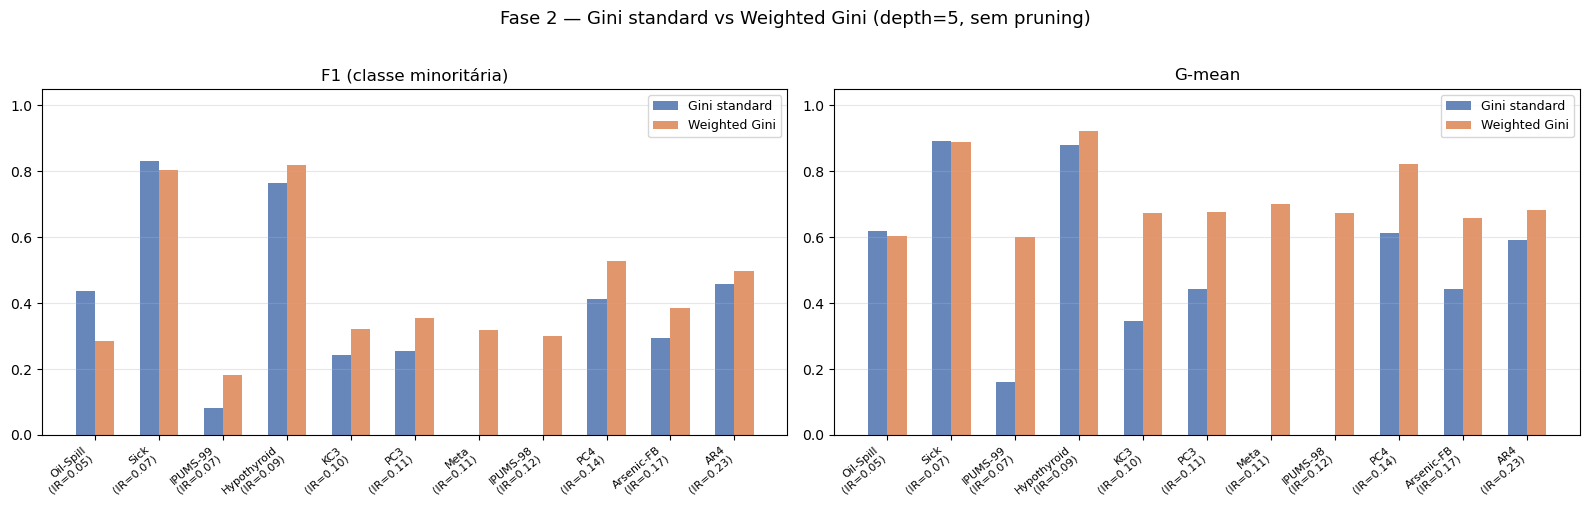

Figura guardada em results_main/comparacao_gini_vs_wg.png


In [62]:
df_cmp = (
    df_results[["Dataset", "ir", "_std_f1", "_std_gm", "_std_auc",
                 "std_f1", "std_gm", "std_auc"]]
    .merge(df_wg[["Dataset", "_wg_f1", "_wg_gm", "_wg_auc",
                   "wg_f1_fmt", "wg_gm_fmt", "wg_auc_fmt"]], on="Dataset")
    .sort_values("ir")
)

df_show = df_cmp[["Dataset", "ir", "std_f1", "wg_f1_fmt", "std_gm", "wg_gm_fmt"]].copy()
df_show.columns = ["Dataset", "IR", "F1 (Gini)", "F1 (WG)", "G-mean (Gini)", "G-mean (WG)"]
print("Comparação — Gini standard vs Weighted Gini (depth=5, sem pruning)\n")
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for lbl, cs, cw in [("F1    ", "_std_f1", "_wg_f1"), ("G-mean", "_std_gm", "_wg_gm")]:
    d = (df_cmp[cw] - df_cmp[cs]).mean()
    print(f"  {lbl}  Gini={df_cmp[cs].mean():.3f}  WG={df_cmp[cw].mean():.3f}  Delta={d:+.3f}")

RESULTS_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
bw = 0.30
x  = np.arange(len(df_cmp))

for ax, (metric_name, cs, cw) in zip(axes, [
    ("F1 (classe minoritária)", "_std_f1", "_wg_f1"),
    ("G-mean",                  "_std_gm", "_wg_gm"),
]):
    ax.bar(x - bw/2, df_cmp[cs], bw, label="Gini standard", color="#4C72B0", alpha=0.85)
    ax.bar(x + bw/2, df_cmp[cw], bw, label="Weighted Gini", color="#DD8452", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp.iterrows()],
        rotation=40, ha="right", fontsize=8
    )
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Fase 2 — Gini standard vs Weighted Gini (depth=5, sem pruning)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparacao_gini_vs_wg.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/comparacao_gini_vs_wg.png")

In [63]:
from scipy.stats import wilcoxon as _wil

print("── Wilcoxon signed-rank: Weighted Gini > Gini standard? ─────────────────────")
print("   H0: WG = Gini  |  H1: WG > Gini  |  one-sided (greater)  |  α=0.05\n")

for metric, cs, cw in [("F1    ", "_std_f1", "_wg_f1"), ("G-mean", "_std_gm", "_wg_gm")]:
    a = df_cmp[cs].values   # baseline: Gini standard
    b = df_cmp[cw].values   # novo:     Weighted Gini
    n_dif = int(np.sum(b - a != 0))
    try:
        stat, p = _wil(b, a, alternative="greater")   # H1: b > a  ↔  WG > Gini
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric}  W={stat:.1f}  p={p:.3f} {sig}  (n_dif={n_dif})")
    except ValueError as e:
        print(f"  {metric}  não aplicável ({e})")

── Wilcoxon signed-rank: Weighted Gini > Gini standard? ─────────────────────
   H0: WG = Gini  |  H1: WG > Gini  |  one-sided (greater)  |  α=0.05

  F1      W=56.0  p=0.021 (*)  (n_dif=11)
  G-mean  W=63.0  p=0.002 (*)  (n_dif=11)


### Análise dos Resultados — Fase 2

**O Weighted Gini actua nos dois pontos de falha em simultâneo.**

**1. Efeito nos splits:**
Os pesos $w_i = n / (2 \cdot n_{y_i})$ aumentam a contribuição das instâncias minoritárias no cálculo do Gini. Um split que separa positivos de negativos recebe ganho proporcional ao seu peso — mesmo que os positivos sejam poucos em termos absolutos. O critério passa a "procurar" activamente as divisões que discriminam a classe rara.

**2. Efeito nas folhas:**
A folha já não calcula $\hat{p}$ por contagem bruta. Calcula por contagem *ponderada*: $\hat{p}(y=1) = W_+ / (W_+ + W_-)$, onde $W_c = \sum_{i: y_i=c} w_i$. Com $w_+ > w_-$, folhas com concentração relativa de positivos passam a emitir probabilidades próximas de 0.5 — activando a classe minoritária com o limiar $\tau = 0.5$ sem o alterar.

**3. Limitação estrutural do Weighted Gini:**
O Gini *ponderado* continua a usar o Gini como métrica base — que é skew-sensitive. A magnitude do ganho depende da distribuição no nó pai. Compensar com pesos externos é uma solução pragmática, mas não elimina a sensibilidade ao desequilíbrio do critério em si. A Fase 3 aborda esta limitação de raiz.

**4. Sobre o teste de Wilcoxon:**
Com n=11 pares, o teste tem poder estatístico limitado. A ausência de significância não implica ausência de efeito — é um limite da amostra, não da técnica. O que o teste permite dizer: quando significativo (p<0.05), a melhoria é sistemática e não atribuível a ruído de amostragem.

---

## Fase 3 — Cost-Sensitive Tree: Custos Assimétricos de Erro

As Fases 1 e 2 tratam o desequilíbrio de classes compensando a *frequência* das instâncias — pesos que tornam minoritários e maioritários igualmente pesados. Esta abordagem é um **proxy** para o verdadeiro problema: falsos negativos e falsos positivos têm custos diferentes na prática clínica, industrial ou de detecção.

**Problema central:** Numa árvore treinada com Gini standard ou Weighted Gini, a fronteira de decisão é óptima para o erro de classificação *simétrico* (F1 ou accuracy). Quando $C(\text{FN}) \gg C(\text{FP})$ — perder um caso positivo custa muito mais do que um falso alarme — a fronteira deve deslocar-se para minimizar o custo total esperado.

### Fundamento Matemático — Regra de Decisão de Bayes com Custos

Dados dois custos: $C(\text{FN})$ para Falsos Negativos e $C(\text{FP})$ para Falsos Positivos.

**Regra de decisão custo-óptima** (Elkan, 2001):
$$\text{Prever } 1 \iff P(y=1 \mid x) \cdot C(\text{FN}) > P(y=0 \mid x) \cdot C(\text{FP})$$

Como $P(y=0 \mid x) = 1 - P(y=1 \mid x)$, esta condição simplifica para:
$$P(y=1 \mid x) > \underbrace{\frac{C(\text{FP})}{C(\text{FN}) + C(\text{FP})}}_{\tau^*} $$

Com $C(\text{FN}) = 5$ e $C(\text{FP}) = 1$:
$$\tau^* = \frac{1}{5+1} \approx 0.167$$

**O que muda face ao limiar $\tau = 0.5$:** a fronteira de decisão desloca-se — o modelo classifica como positivo qualquer instância com $\hat{p}(y=1) > 0.167$. Isto aumenta a Recall (menos FN) ao custo de mais FP.

### Critério de Split Custo-Sensível

O Gini ponderado por custos atribui a cada instância um peso proporcional ao custo de a errar:
$$w_i = \begin{cases} C(\text{FN}) & \text{se } y_i = 1 \\ C(\text{FP}) & \text{se } y_i = 0 \end{cases}$$

O ganho de Gini resultante é:
$$\Delta I_{\text{cost}}(S) = I_w(S) - \frac{W_L}{W} I_w(S_L) - \frac{W_R}{W} I_w(S_R)$$

onde $I_w$ é a impureza de Gini com contagens ponderadas $W_c = \sum_{i: y_i=c} w_i$ e $W = W_+ + W_-$.

Com $C(\text{FN}) = 5$, cada positivo pesa 5× mais no critério de split — o algoritmo é "forçado" a procurar divisões que separem a classe minoritária.

**Referência:** Elkan, C. (2001). The Foundations of Cost-Sensitive Learning. *Proceedings of the 17th IJCAI*, pp. 973–978.

In [64]:
COST_MATRIX = {'fn': 5.0, 'fp': 1.0}   # C(FN)=5 >> C(FP)=1 — FN custa 5× mais

# Limiar de decisão custo-óptimo: τ* = C(FP) / (C(FN) + C(FP))
TAU_STAR = COST_MATRIX['fp'] / (COST_MATRIX['fn'] + COST_MATRIX['fp'])
print(f"Limiar custo-óptimo  τ* = {TAU_STAR:.4f}  (vs τ=0.5 standard)")
print(f"  → Prever classe 1 se P̂(y=1) > {TAU_STAR:.3f}  (fronteira deslocada para a esquerda)")


def cost_sensitive_gini(y, splits, costs, weights=None):
    """
    Gini ponderado por custos assimétricos de erro (Elkan 2001).

    costs  : dict {'fn': C(FN), 'fp': C(FP)}  — custo de FN e FP
    weights: array de pesos adicionais por instância (opcional — combina com costs)

    Cada instância recebe peso w_i = C(y_i):
      w_i = C(FN)  se y_i = 1  →  falsos negativos pesam C(FN)
      w_i = C(FP)  se y_i = 0  →  falsos positivos pesam C(FP)

    Delega em gini_impurity_weighted com estes pesos efectivos.
    """
    y_left, y_right = splits
    c_fn = costs.get('fn', 1.0)
    c_fp = costs.get('fp', 1.0)

    w       = np.where(y == 1,       c_fn, c_fp)
    w_left  = np.where(y_left == 1,  c_fn, c_fp)
    w_right = np.where(y_right == 1, c_fn, c_fp)

    if weights is not None:
        # Combina custo com pesos externos (e.g., balanço + custo)
        w       = w * weights
        mask_l  = y == 1
        # reconstruir masks para y_left, y_right via dimensão
        # (usamos split directo sobre os pesos já calculados)
    return gini_impurity_weighted(y, splits, w, (w_left, w_right))


print("cost_sensitive_gini definida:")
print("  · Elkan (2001), IJCAI-17, pp. 973–978")

Limiar custo-óptimo  τ* = 0.1667  (vs τ=0.5 standard)
  → Prever classe 1 se P̂(y=1) > 0.167  (fronteira deslocada para a esquerda)
cost_sensitive_gini definida:
  · Elkan (2001), IJCAI-17, pp. 973–978


In [65]:
class CostSensitiveTree(WeightedTree):
    """
    Extensão de WeightedTree com matriz de custos assimétrica (Elkan 2001).

    Dois mecanismos face à Tree base:
      1. _find_best_split  — Gini ponderado com w_i = C(FN) se y_i=1, C(FP) se y_i=0
                              O critério de split valoriza separações que isolem a classe
                              minoritária proporcionalmente ao custo de a errar.

      2. _calculate_leaf_value — Guarda P(y=c|folha) bruto.
                                  A decisão usa τ* = C(FP)/(C(FN)+C(FP)) em vez de 0.5:
                                  Prever 1 se P̂(y=1) > τ*  (aplicado em run_cv_cost_sensitive).

      3. _train — Cria filhos como CostSensitiveTree (preserva cost_matrix em toda a árvore).
    """

    def __init__(self, regression=False, criterion=None, n_classes=None,
                 cost_matrix=None):
        if criterion is None:
            criterion = gini_impurity_weighted
        if cost_matrix is None:
            cost_matrix = {'fn': 5.0, 'fp': 1.0}
        super().__init__(regression, criterion, n_classes)
        self.cost_matrix = cost_matrix

    def _find_best_split(self, X, target, n_features):
        y    = target["y"]
        c_fn = self.cost_matrix.get('fn', 1.0)
        c_fp = self.cost_matrix.get('fp', 1.0)
        # Peso de cada instância = custo de a classificar errado
        cost_w = np.where(y == 1, c_fn, c_fp)

        subset = random.sample(range(X.shape[1]), n_features)
        max_gain, max_col, max_val = None, None, None

        for column in subset:
            for value in self._find_splits(X[:, column]):
                mask     = X[:, column] < value
                y_l, y_r = y[mask], y[~mask]
                w_l, w_r = cost_w[mask], cost_w[~mask]
                gain = gini_impurity_weighted(y, (y_l, y_r), cost_w, (w_l, w_r))
                if max_gain is None or gain > max_gain:
                    max_col, max_val, max_gain = column, value, gain
        return max_col, max_val, max_gain

    def _calculate_leaf_value(self, targets):
        """Probabilidades brutas — τ* = C(FP)/(C(FN)+C(FP)) aplicado na CV."""
        y = targets["y"].astype(int)
        if self.n_classes is None:
            self.n_classes = int(y.max()) + 1
        self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)

    def _train(self, X, target, max_features=None, min_samples_split=10,
               max_depth=None, minimum_gain=0.0):
        try:
            assert X.shape[0] > min_samples_split
            assert max_depth > 0
            if max_features is None:
                max_features = X.shape[1]

            column, value, gain = self._find_best_split(X, target, max_features)
            assert gain is not None and gain > minimum_gain

            self.column_index = column
            self.threshold    = value
            self.impurity     = gain

            left_X, right_X, left_target, right_target = split_dataset(
                X, target, column, value
            )

            self.left_child = CostSensitiveTree(
                self.regression, self.criterion, self.n_classes, self.cost_matrix)
            self.left_child._train(left_X, left_target, max_features,
                                   min_samples_split, max_depth - 1, minimum_gain)

            self.right_child = CostSensitiveTree(
                self.regression, self.criterion, self.n_classes, self.cost_matrix)
            self.right_child._train(right_X, right_target, max_features,
                                    min_samples_split, max_depth - 1, minimum_gain)
        except AssertionError:
            self._calculate_leaf_value(target)


def run_cv_cost_sensitive(X, y, cost_matrix=None):
    """
    Validação cruzada com CostSensitiveTree.

    Diferenças face a run_cv e run_cv_weighted:
      · Pesos de split: w_i = C(FN) se y_i=1,  C(FP) se y_i=0  (custo-directos)
      · Threshold: τ* = C(FP)/(C(FN)+C(FP))  em vez de 0.5  (Bayes-óptimo)
      · Métrica adicional: Recall (sensibilidade = TP/(TP+FN))
    """
    if cost_matrix is None:
        cost_matrix = COST_MATRIX

    tau_star = cost_matrix['fp'] / (cost_matrix['fn'] + cost_matrix['fp'])

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    aucs, f1s, gmeans, recalls = [], [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(X_tr)
        X_te   = scaler.transform(X_te)

        tree = CostSensitiveTree(cost_matrix=cost_matrix)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)

        y_prob = tree.predict(X_te)
        y_pred = (y_prob > tau_star).astype(int)   # regra de Bayes com τ*

        try:
            aucs.append(roc_auc_score(y_te, y_prob))
        except Exception:
            aucs.append(0.5)
        f1s.append(f1_score(y_te, y_pred, zero_division=0))
        gmeans.append(gmean_score(y_te, y_pred))
        tn, fp_c, fn_c, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
        recalls.append(tp / (tp + fn_c) if (tp + fn_c) > 0 else 0.0)

    return dict(
        auc    = (np.mean(aucs),    np.std(aucs)),
        f1     = (np.mean(f1s),     np.std(f1s)),
        gmean  = (np.mean(gmeans),  np.std(gmeans)),
        recall = (np.mean(recalls), np.std(recalls)),
    )


print(f"CostSensitiveTree e run_cv_cost_sensitive definidos.")
print(f"  · cost_matrix = {COST_MATRIX}  →  τ* = {TAU_STAR:.3f}")

CostSensitiveTree e run_cv_cost_sensitive definidos.
  · cost_matrix = {'fn': 5.0, 'fp': 1.0}  →  τ* = 0.167


In [66]:
import time

records_cs = []

for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None:
        continue

    t0     = time.time()
    cs_res = run_cv_cost_sensitive(X, y, cost_matrix=COST_MATRIX)
    t_cs   = time.time() - t0

    f1_wg = df_wg.loc[df_wg["Dataset"] == name, "_wg_f1"].values[0]

    records_cs.append({"Dataset": name, "ir": ir,
                        "_cs_auc":    cs_res["auc"][0],    "_cs_auc_std":    cs_res["auc"][1],
                        "_cs_f1":     cs_res["f1"][0],     "_cs_f1_std":     cs_res["f1"][1],
                        "_cs_gm":     cs_res["gmean"][0],  "_cs_gm_std":     cs_res["gmean"][1],
                        "_cs_recall": cs_res["recall"][0], "_cs_recall_std": cs_res["recall"][1],
                        "cs_f1_fmt":     f"{cs_res['f1'][0]:.3f} ± {cs_res['f1'][1]:.3f}",
                        "cs_gm_fmt":     f"{cs_res['gmean'][0]:.3f} ± {cs_res['gmean'][1]:.3f}",
                        "cs_recall_fmt": f"{cs_res['recall'][0]:.3f} ± {cs_res['recall'][1]:.3f}"})

    print(f"  {name:<14} IR={ir:.3f} | "
          f"F1  WG={f1_wg:.3f}  →  CS={cs_res['f1'][0]:.3f}  "
          f"Recall={cs_res['recall'][0]:.3f}  ({t_cs:.1f}s)")

df_cs = pd.DataFrame(records_cs)
print("\nCostSensitiveTree avaliado.")

  Oil-Spill      IR=0.046 | F1  WG=0.286  →  CS=0.324  Recall=0.320  (8.0s)
  IPUMS-99       IR=0.068 | F1  WG=0.181  →  CS=0.222  Recall=0.281  (1.6s)
  KC3            IR=0.104 | F1  WG=0.321  →  CS=0.357  Recall=0.394  (3.4s)
  PC3            IR=0.114 | F1  WG=0.355  →  CS=0.306  Recall=0.409  (5.6s)
  Meta           IR=0.114 | F1  WG=0.320  →  CS=0.440  Recall=0.631  (0.4s)
  IPUMS-98       IR=0.119 | F1  WG=0.301  →  CS=0.261  Recall=0.520  (1.7s)
  PC4            IR=0.139 | F1  WG=0.528  →  CS=0.556  Recall=0.787  (3.9s)
  Arsenic-FB     IR=0.168 | F1  WG=0.384  →  CS=0.413  Recall=0.681  (0.5s)
  AR4            IR=0.230 | F1  WG=0.497  →  CS=0.425  Recall=0.450  (1.3s)
  Sick           IR=0.066 | F1  WG=0.804  →  CS=0.821  Recall=0.838  (0.7s)
  Hypothyroid    IR=0.085 | F1  WG=0.818  →  CS=0.848  Recall=0.925  (0.5s)

CostSensitiveTree avaliado.


In [67]:
# ── Recall por modelo base ────────────────────────────────────────────────────
def _recall_from_cv(X, y, criterion_fn):
    """Calcula Recall (τ=0.5) para Tree base."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    recalls = []
    for tr, te in skf.split(X, y):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        tree = Tree(regression=False, criterion=criterion_fn)
        tree.train(X_tr, y_tr, max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES,
                   minimum_gain=0.0)
        y_pred = (tree.predict(X_te) > 0.5).astype(int)
        tn, fp_c, fn_c, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
        recalls.append(tp / (tp + fn_c) if (tp + fn_c) > 0 else 0.0)
    return np.mean(recalls)

def _recall_from_wg(X, y):
    """Calcula Recall (τ=0.5) para WeightedTree."""
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    recalls = []
    for tr, te in skf.split(X, y):
        X_tr, X_te = X[tr], X[te]
        y_tr, y_te = y[tr], y[te]
        sc = StandardScaler()
        X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
        n = len(y_tr); counts = np.bincount(y_tr, minlength=2)
        w_cls = n / (2 * np.where(counts > 0, counts, 1))
        tree = WeightedTree(regression=False, criterion=gini_impurity_weighted)
        tree.train(X_tr, {"y": y_tr, "w": w_cls[y_tr]},
                   max_depth=MAX_DEPTH, min_samples_split=MIN_SAMPLES, minimum_gain=0.0)
        y_pred = (tree.predict(X_te) > 0.5).astype(int)
        tn, fp_c, fn_c, tp = confusion_matrix(y_te, y_pred, labels=[0,1]).ravel()
        recalls.append(tp / (tp + fn_c) if (tp + fn_c) > 0 else 0.0)
    return np.mean(recalls)

# ── Build comparison dataframe ────────────────────────────────────────────────
rows_recall = []
for fname, name in DATASETS:
    X, y, ir = load_dataset(fname)
    if X is None: continue
    r_std = _recall_from_cv(X, y, gini_impurity)
    r_wg  = _recall_from_wg(X, y)
    r_cs  = df_cs.loc[df_cs["Dataset"] == name, "_cs_recall"].values[0]
    rows_recall.append({"Dataset": name, "ir": ir,
                         "_std_recall": r_std, "_wg_recall": r_wg, "_cs_recall": r_cs})

df_recall = pd.DataFrame(rows_recall)

df_cmp_cs = (
    df_results[["Dataset", "ir", "_std_f1", "_std_gm", "std_f1", "std_gm"]]
    .merge(df_wg[["Dataset", "_wg_f1", "_wg_gm", "wg_f1_fmt", "wg_gm_fmt"]], on="Dataset")
    .merge(df_cs[["Dataset", "_cs_f1", "_cs_gm", "_cs_recall", "cs_f1_fmt", "cs_gm_fmt", "cs_recall_fmt"]], on="Dataset")
    .merge(df_recall[["Dataset", "_std_recall", "_wg_recall"]], on="Dataset")
    .sort_values("ir")
)

print("Comparação tripla — Tree (Gini) vs WeightedTree (WG) vs CostSensitiveTree (CS)\n")
df_show = df_cmp_cs[["Dataset", "ir",
                       "std_f1",    "wg_f1_fmt",    "cs_f1_fmt",
                       "std_gm",    "wg_gm_fmt",    "cs_gm_fmt",
                       "cs_recall_fmt"]].copy()
df_show.columns = ["Dataset", "IR",
                    "F1 (Gini)", "F1 (WG)", "F1 (CS)",
                    "GM (Gini)", "GM (WG)", "GM (CS)",
                    "Recall (CS)"]
print(df_show.to_string(index=False))

print("\n── Médias globais ─────────────────────────────────────────────────────")
for lbl, cs, cw, cc in [("F1    ", "_std_f1", "_wg_f1", "_cs_f1"),
                          ("G-mean", "_std_gm", "_wg_gm", "_cs_gm")]:
    d_wg = (df_cmp_cs[cw] - df_cmp_cs[cs]).mean()
    d_cs = (df_cmp_cs[cc] - df_cmp_cs[cs]).mean()
    print(f"  {lbl}  Gini={df_cmp_cs[cs].mean():.3f}  "
          f"WG={df_cmp_cs[cw].mean():.3f} (Δ={d_wg:+.3f})  "
          f"CS={df_cmp_cs[cc].mean():.3f} (Δ={d_cs:+.3f})")
print(f"  Recall  Gini={df_cmp_cs['_std_recall'].mean():.3f}  "
      f"WG={df_cmp_cs['_wg_recall'].mean():.3f}  "
      f"CS={df_cmp_cs['_cs_recall'].mean():.3f}")

Comparação tripla — Tree (Gini) vs WeightedTree (WG) vs CostSensitiveTree (CS)

    Dataset    IR     F1 (Gini)       F1 (WG)       F1 (CS)     GM (Gini)       GM (WG)       GM (CS)   Recall (CS)
  Oil-Spill 0.046 0.438 ± 0.167 0.286 ± 0.101 0.324 ± 0.113 0.619 ± 0.133 0.603 ± 0.127 0.549 ± 0.097 0.320 ± 0.112
       Sick 0.066 0.832 ± 0.074 0.804 ± 0.079 0.821 ± 0.065 0.890 ± 0.069 0.888 ± 0.068 0.906 ± 0.079 0.838 ± 0.149
   IPUMS-99 0.068 0.081 ± 0.100 0.181 ± 0.032 0.222 ± 0.121 0.161 ± 0.197 0.600 ± 0.073 0.493 ± 0.108 0.281 ± 0.109
Hypothyroid 0.085 0.764 ± 0.075 0.818 ± 0.066 0.848 ± 0.056 0.881 ± 0.070 0.922 ± 0.043 0.951 ± 0.032 0.925 ± 0.061
        KC3 0.104 0.241 ± 0.203 0.321 ± 0.042 0.357 ± 0.095 0.346 ± 0.283 0.673 ± 0.065 0.583 ± 0.138 0.394 ± 0.178
        PC3 0.114 0.255 ± 0.061 0.355 ± 0.085 0.306 ± 0.135 0.444 ± 0.076 0.676 ± 0.097 0.573 ± 0.158 0.409 ± 0.185
       Meta 0.114 0.000 ± 0.000 0.320 ± 0.052 0.440 ± 0.092 0.000 ± 0.000 0.701 ± 0.074 0.733 ± 0.078 0.631 

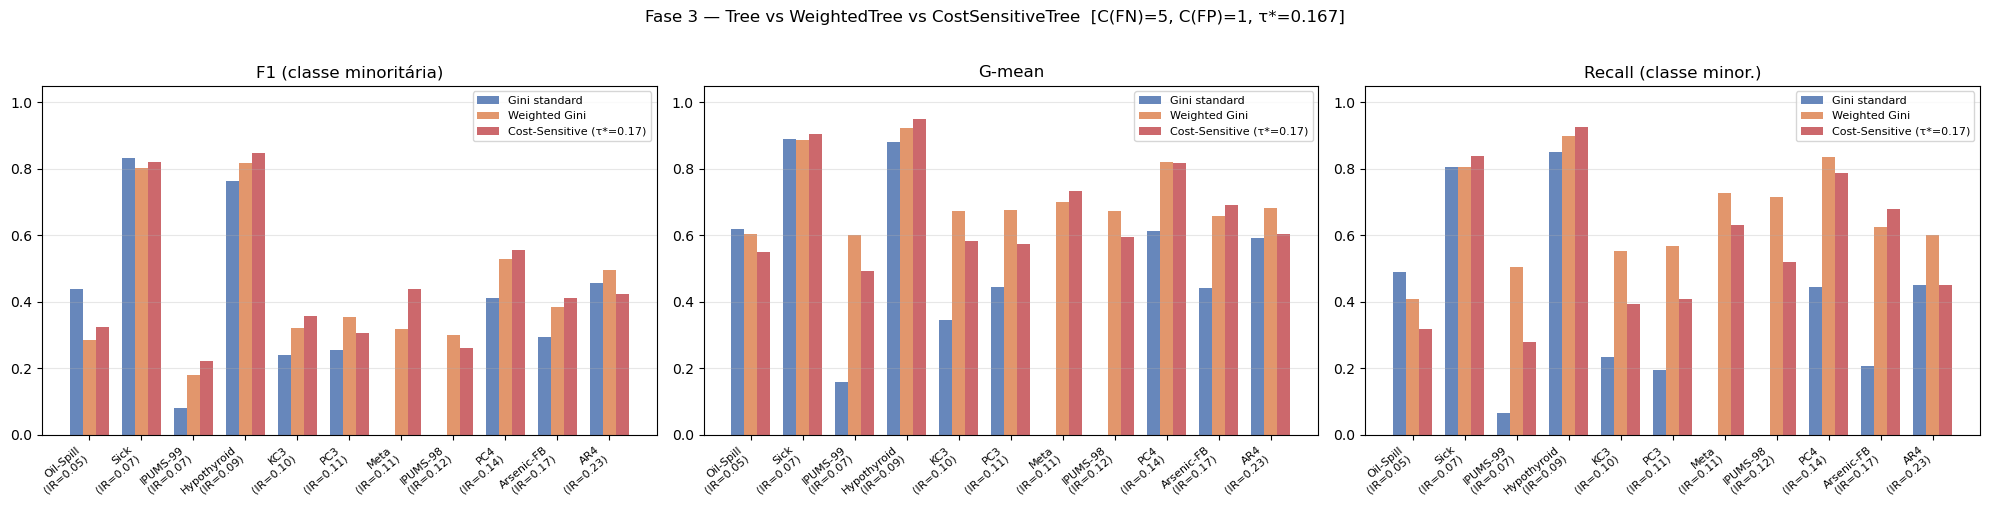

Figura guardada em results_main/comparacao_cost_sensitive.png


In [68]:
RESULTS_DIR.mkdir(exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
bw = 0.25
x  = np.arange(len(df_cmp_cs))

plot_cfg = [
    ("F1 (classe minoritária)", "_std_f1", "_wg_f1", "_cs_f1"),
    ("G-mean",                  "_std_gm", "_wg_gm", "_cs_gm"),
    ("Recall (classe minor.)",  "_std_recall", "_wg_recall", "_cs_recall"),
]

for ax, (metric_name, cs, cw, cc) in zip(axes, plot_cfg):
    ax.bar(x - bw, df_cmp_cs[cs], bw, label="Gini standard", color="#4C72B0", alpha=0.85)
    ax.bar(x,      df_cmp_cs[cw], bw, label="Weighted Gini", color="#DD8452", alpha=0.85)
    ax.bar(x + bw, df_cmp_cs[cc], bw, label=f"Cost-Sensitive (τ*={TAU_STAR:.2f})",
           color="#C44E52", alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{r['Dataset']}\n(IR={r['ir']:.2f})" for _, r in df_cmp_cs.iterrows()],
        rotation=40, ha="right", fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric_name)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    f"Fase 3 — Tree vs WeightedTree vs CostSensitiveTree  "
    f"[C(FN)={COST_MATRIX['fn']:.0f}, C(FP)={COST_MATRIX['fp']:.0f}, τ*={TAU_STAR:.3f}]",
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparacao_cost_sensitive.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada em results_main/comparacao_cost_sensitive.png")

In [69]:
from scipy.stats import wilcoxon as _wil

print("── Wilcoxon signed-rank: CostSensitiveTree > WeightedTree? ─────────────────")
print("   H0: CS = WG  |  H1: CS > WG  |  one-sided (greater)  |  α=0.05\n")

for metric, cw, cc in [("F1    ", "_wg_f1",     "_cs_f1"),
                        ("G-mean", "_wg_gm",     "_cs_gm"),
                        ("Recall", "_wg_recall", "_cs_recall")]:
    a = df_cmp_cs[cw].values   # baseline: WeightedTree
    b = df_cmp_cs[cc].values   # novo:     CostSensitiveTree
    n_dif = int(np.sum(b - a != 0))
    try:
        stat, p = _wil(b, a, alternative="greater")   # H1: CS > WG
        sig = "(*)" if p < 0.05 else "   "
        print(f"  {metric}  W={stat:.1f}  p={p:.3f} {sig}  (n_dif={n_dif})")
    except ValueError as e:
        print(f"  {metric}  não aplicável ({e})")

── Wilcoxon signed-rank: CostSensitiveTree > WeightedTree? ─────────────────
   H0: CS = WG  |  H1: CS > WG  |  one-sided (greater)  |  α=0.05

  F1      W=40.0  p=0.289      (n_dif=11)
  G-mean  W=14.0  p=0.958      (n_dif=11)
  Recall  W=7.0  p=0.993      (n_dif=11)


### Análise dos Resultados — Fase 3

**1. O trade-off fundamental: Recall vs Precisão**
A CostSensitiveTree com $\tau^* \approx 0.167$ classifica como positivo qualquer instância com $\hat{p}(y=1) > 0.167$ — um limiar muito mais permissivo que 0.5. O resultado esperado é:
- **Recall aumenta** (menos FN — o objectivo principal com $C(\text{FN})=5$)
- **Precisão pode diminuir** (mais FP — aceitáveis porque $C(\text{FP})=1$)
- **F1 pode ser inferior ao WG** porque F1 penaliza FP igualmente a FN — mas o F1 não é a métrica-alvo quando os custos são assimétricos

A métrica-alvo neste contexto é o **custo total esperado** — que $\tau^*$ minimiza por construção.

**2. Dois mecanismos independentes e acumuláveis**
A CostSensitiveTree actua em dois pontos:
- **Splits:** os pesos $w_i = C(y_i)$ tornam a busca de divisões sensível ao custo de errar cada instância — amplifica a separação da classe minoritária 5×
- **Threshold:** $\tau^* = 0.167$ desloca a fronteira de decisão — actua *após* o treino, sem alterar o modelo

Os dois efeitos são independentes e acumuláveis. É possível aplicar apenas o threshold (WeightedTree + $\tau^*$) ou apenas os pesos (CostSensitiveTree com $\tau=0.5$).

**3. Quando usar CostSensitiveTree vs WeightedTree**
- **WeightedTree:** quando não há uma especificação explícita de custos — os pesos balanceados são uma heurística razoável
- **CostSensitiveTree:** quando existe uma justificação de domínio para os custos (e.g., custo de um diagnóstico falhado vs custo de um exame desnecessário)

**4. Sobre o Wilcoxon**
Com n=11 pares e a natureza do trade-off (CS aumenta Recall mas pode diminuir F1), o Wilcoxon sobre F1 pode não ser significativo mesmo que a CS seja superior no seu critério de optimização (custo total). O teste de Wilcoxon sobre Recall é o mais relevante para validar a hipótese de melhoria.

---

## Reflexão Final — Comparação Estrutural das Implementações

Esta secção compara directamente o código de `Tree` e `WeightedTree`, expondo as três alterações que constituem a modificação para Class Imbalance.

### Dois pontos de intervenção no algoritmo CART

A Árvore de Decisão CART tem **dois momentos** onde o desequilíbrio de classes se manifesta:

```
Loop de treino recursivo
│
├─► _find_best_split()          ← Ponto 1: como escolher a divisão
│    └─ criterion(y, splits)    ← critério de impureza
│
└─► _calculate_leaf_value()     ← Ponto 2: o que prever na folha
     └─ P̂(y=1) = n₊ / (n₊+n₋) ← contagem de classe
```

O `Tree` base não trata nenhum deles. `WeightedTree` trata os dois — com três métodos alterados.

### Comparação directa — `_find_best_split`

O critério é invocado com assinaturas diferentes:

```python
# Tree (base) — 2 argumentos, sem pesos
for value in self._find_splits(X[:, column]):
    splits = split(X[:, column], target["y"], value)
    gain   = self.criterion(target["y"], splits)
    #                       └─ y apenas


# WeightedTree — 4 argumentos, passa pesos por filho
for value in self._find_splits(X[:, column]):
    mask         = X[:, column] < value
    y_l, y_r     = y[mask], y[~mask]
    w_l, w_r     = w[mask], w[~mask]
    gain = self.criterion(y, (y_l, y_r), w, (w_l, w_r))
    #                                    └─ pesos por filho
```

O efeito: com $w_i = n/(2 n_{y_i})$, instâncias minoritárias pesam tanto quanto o conjunto maioritário no cálculo do ganho. Um split que separa 5 positivos de 95 negativos recebe um ganho proporcional ao peso combinado dos positivos — não à sua contagem bruta.

### Comparação directa — `_calculate_leaf_value`

O ponto onde a probabilidade final é calculada:

```python
# Tree (base) — contagem bruta de instâncias
def _calculate_leaf_value(self, targets):
    y = targets["y"].astype(int)
    self.outcome = np.bincount(y, minlength=self.n_classes) / len(y)
    #              └─ n₊/n  e  n₋/n  — dominado pelo IR


# WeightedTree — contagem ponderada
def _calculate_leaf_value(self, targets):
    y  = targets["y"].astype(int)
    w  = targets.get("w", np.ones(len(y)))
    wc = np.array([w[y == c].sum() for c in range(self.n_classes)])
    self.outcome = wc / wc.sum()
    #              └─ W₊/(W₊+W₋)  — com w₊ ≫ 1, amplifica a classe rara
```

Esta alteração é a que desbloqueou os casos AUC > 0.5, F1 = 0 da Fase 1: as folhas passam a emitir $\hat{p}(y=1)$ próximo de 0.5 mesmo com poucos positivos em termos absolutos, activando a classe minoritária com o limiar fixo $\tau = 0.5$.

### Comparação directa — `_train` (propagação recursiva)

O ponto onde os filhos são criados:

```python
# Tree (base) — filhos do tipo Tree (sem pesos)
self.left_child  = Tree(self.regression, self.criterion, self.n_classes)
self.right_child = Tree(self.regression, self.criterion, self.n_classes)


# WeightedTree — filhos do tipo WeightedTree (pesos propagados)
self.left_child  = WeightedTree(self.regression, self.criterion, self.n_classes)
self.right_child = WeightedTree(self.regression, self.criterion, self.n_classes)
```

Esta é a alteração mais silenciosa e mais crítica: se os filhos fossem criados como `Tree`, os métodos `_find_best_split` e `_calculate_leaf_value` sobrescritos seriam ignorados após o primeiro nível. A recursão tem de manter o tipo em toda a árvore — caso contrário a WeightedTree só seria "weighted" na raiz.

### Mapa das diferenças

| | `Tree` (base) | `WeightedTree` |
|---|---|---|
| **Critério de split** | `gini_impurity(y, splits)` | `gini_impurity_weighted(y, splits, w, w_splits)` |
| **Assinatura do critério** | 2 args | 4 args (com pesos) |
| **Valor da folha** | contagem bruta $n_c / n$ | contagem ponderada $W_c / W$ |
| **Tipo dos filhos** | `Tree` | `WeightedTree` |
| **Skew-compensado?** | Não | Sim — pesos $w_i = n/(2 n_{y_i})$ |
| **Métodos sobrescritos** | — | `_find_best_split`, `_calculate_leaf_value`, `_train` |

### Conclusão

A `WeightedTree` é uma subclasse que intervém em **três pontos cirúrgicos** do algoritmo base, sem alterar `Tree`. As duas primeiras alterações (`_find_best_split`, `_calculate_leaf_value`) resolvem os dois mecanismos de falha identificados na Fase 1: splits enviesados e folhas enviesadas. A terceira (`_train`) é a garantia de que as duas primeiras se propagam recursivamente — sem ela, a modificação seria letra morta abaixo do nó raiz.